In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import import_ipynb
from simca import SIMCAModel, SIMCAClassModel

Number of XVOO_NONE NIR measurements: 10
NIR spectra shape: (10, 228)


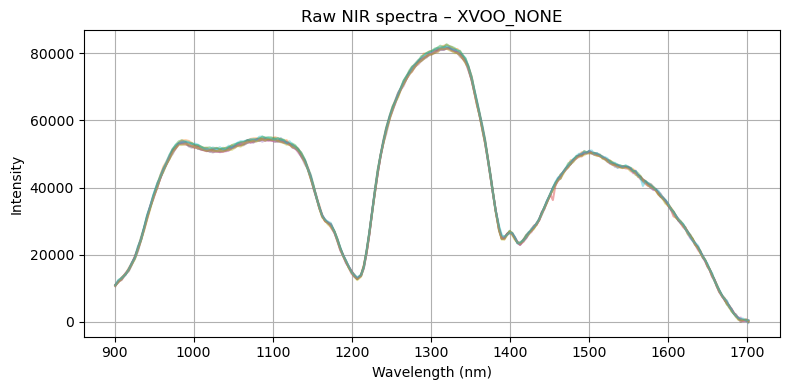

Number of XVOO_NONE VIS measurements: 10
VIS spectra shape: (10, 288)


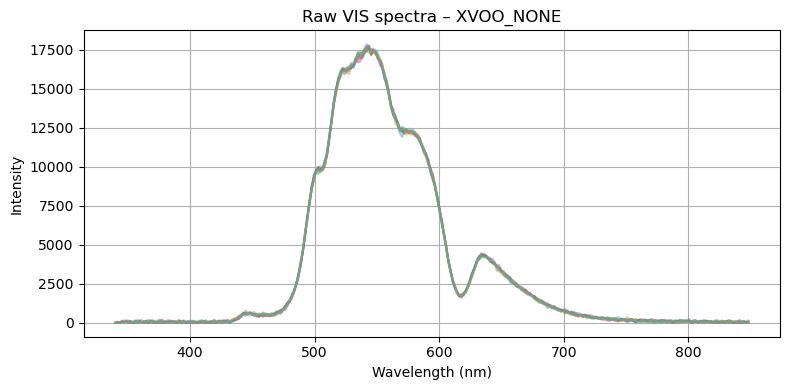

Number of XVOO_NONE FLUO measurements: 10
FLUO spectra shape: (10, 288)


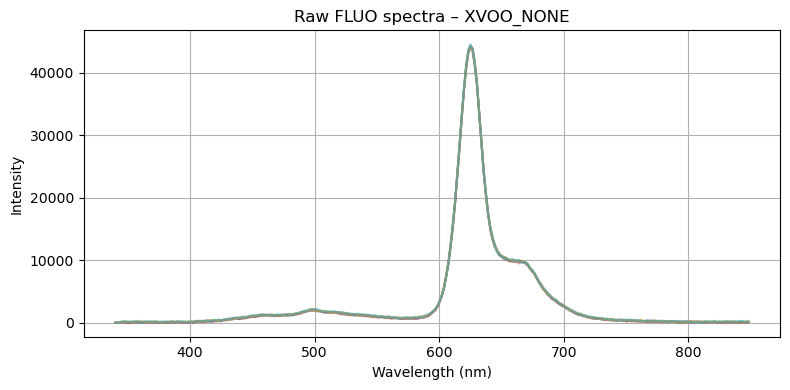

In [12]:
base_path = r"data/Replicate_011/Replicate_011_20251119/xvoo_none"
spectra_types = ["NIR", "VIS", "FLUO"]

xvoo_none_spectra = {}
wavelengths_dict = {}

for spec_type in spectra_types:
    spec_path = os.path.join(base_path, spec_type)
    spec_files = sorted(glob.glob(os.path.join(spec_path, "*.csv")))
    
    print(f"Number of XVOO_NONE {spec_type} measurements: {len(spec_files)}")
    
    spectra_list = []
    for i, fpath in enumerate(spec_files):
        df = pd.read_csv(fpath)
        
        if i == 0:
            wavelengths_dict[spec_type] = df.iloc[:, 0].values
        
        spectra_list.append(df.iloc[:, 1].values)
    
    xvoo_none_spectra[spec_type] = np.array(spectra_list)
    print(f"{spec_type} spectra shape:", xvoo_none_spectra[spec_type].shape)
    
    plt.figure(figsize=(8, 4))
    for spectrum in xvoo_none_spectra[spec_type]:
        plt.plot(wavelengths_dict[spec_type], spectrum, alpha=0.4)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity")
    plt.title(f"Raw {spec_type} spectra – XVOO_NONE")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [2]:
wr_base_path = "data/Replicate_011_20251205/Replicate_011_20251205/xvoo_none/wr"
spectra_types = ["NIR", "VIS", "FLUO"]

wr_dict = {}
wavelengths_wr_dict = {}

for spec_type in spectra_types:
    wr_file = os.path.join(wr_base_path, f"{spec_type}_WR.csv")
    wr_df = pd.read_csv(wr_file)
    
    wavelengths_wr_dict[spec_type] = wr_df.iloc[:, 0].values
    wr_dict[spec_type] = wr_df.iloc[:, 1].values
    
    print(f"{spec_type} WR shape:", wr_df.shape)
    
    assert np.allclose(wavelengths_dict[spec_type], wavelengths_wr_dict[spec_type]), \
        f"{spec_type} wavelengths and WR wavelengths do NOT match!"
    
    plt.figure(figsize=(8, 4))
    plt.plot(wavelengths_wr_dict[spec_type], wr_dict[spec_type], color='green')
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity")
    plt.title(f"White Reference (WR) – {spec_type}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

NameError: name 'os' is not defined

In [3]:
xvoo_none_norm = {}
epsilon = 1e-10

for spec_type in spectra_types:
    if spec_type in ["NIR", "VIS"]:
        xvoo_none_norm[spec_type] = xvoo_none_spectra[spec_type] / (wr_dict[spec_type] + epsilon)
    else:
        xvoo_none_norm[spec_type] = xvoo_none_spectra[spec_type].copy()
    
    plt.figure(figsize=(8, 4))
    for spectrum in xvoo_none_norm[spec_type]:
        plt.plot(wavelengths_dict[spec_type], spectrum, alpha=0.4)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized intensity" if spec_type != "FLUO" else "Intensity")
    plt.title(f"Normalized {spec_type} spectra – XVOO_NONE")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

NameError: name 'xvoo_none_spectra' is not defined

In [15]:
for spec_type in spectra_types:
    print(f"{spec_type} normalized spectra shape:", xvoo_none_norm[spec_type].shape)

NIR normalized spectra shape: (10, 228)
VIS normalized spectra shape: (10, 288)
FLUO normalized spectra shape: (10, 288)


In [16]:
X_none_fused = np.array([
    np.concatenate([xvoo_none_norm["NIR"][i],
                    xvoo_none_norm["VIS"][i],
                    xvoo_none_norm["FLUO"][i]])
    for i in range(xvoo_none_norm["NIR"].shape[0])
])

y_none = np.array(["XVOO_NONE"] * X_none_fused.shape[0])

print("Fused XVOO_NONE shape:", X_none_fused.shape)

Fused XVOO_NONE shape: (10, 804)


In [17]:
simca_fused = SIMCAModel(alpha=0.05, default_n_components=None)

comp_grid = list(range(1, min(10, X_none_fused.shape[1]) + 1))
best_components = simca_fused.tune_num_components(
    X_none_fused, y_none,
    comp_grid=comp_grid,
    cv=5,
    mode='rigorous',    # 'rigorous', 'compliant'
    rule='sim',         # 'sim', 'alt', 'ci', 'dd'
    od_method='percentile',    # 'percentile', 'jackson', 'box'
    sd_method='f'              # 'f', 'chi2', 'percentile'
)
print("Optimal number of PCA components per class:", best_components)

simca_fused.fit(X_none_fused, y_none, n_components=list(best_components.values())[0])
simca_fused.set_thresholds_all(od_method='percentile', sd_method='f')

Optimal number of PCA components per class: {'XVOO_NONE': 1}


SIMCA thresholds (fused spectra):
ODcrit: 1.1856818367608148e+25
SDcrit: 5.62909053211915
Inside class (True = sample accepted): [ True  True  True  True False  True  True  True  True  True]


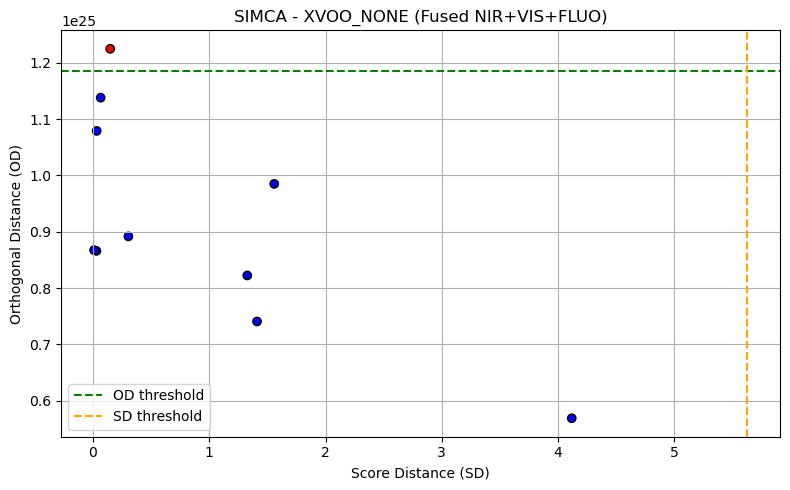

In [18]:
results_fused = simca_fused.predict(X_none_fused, rule='sim')
res_fused = results_fused['XVOO_NONE']

print("SIMCA thresholds (fused spectra):")
print("ODcrit:", res_fused.get('ODcrit', None))
print("SDcrit:", res_fused.get('SDcrit', None))
print("Inside class (True = sample accepted):", res_fused['inside'])

plt.figure(figsize=(8,5))
colors = np.where(res_fused['inside'], 'blue', 'red')
plt.scatter(res_fused['SD'], res_fused['OD'], c=colors, edgecolor='k')
plt.axhline(simca_fused.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
plt.axvline(simca_fused.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')
plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA - XVOO_NONE (Fused NIR+VIS+FLUO)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
base_folder = r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011_20251205\Replicate_011_20251205\xvoo_mix"
mixtures = ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40", "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]

spectra_types = ["NIR", "VIS", "FLUO"]
wr_files = {
    "NIR": os.path.join(base_folder, "wr", "NIR_WR.csv"),
    "VIS": os.path.join(base_folder, "wr", "VIS_WR.csv")
}
epsilon = 1e-10

wr_dict_mix = {}
for spec_type in ["NIR", "VIS"]:
    wr_df = pd.read_csv(wr_files[spec_type])
    wr_dict_mix[spec_type] = wr_df.iloc[:, 1].values

mix_spectra_norm = {spec: [] for spec in spectra_types}
mix_labels = []

for mix in mixtures:
    for spec_type in spectra_types:
        spec_folder = os.path.join(base_folder, mix, spec_type)
        if not os.path.exists(spec_folder):
            print(f"Upozorenje: folder ne postoji {spec_folder}, preskačem...")
            continue
        
        files = sorted([f for f in os.listdir(spec_folder) if f.endswith(".csv")])
        for f in files:
            df = pd.read_csv(os.path.join(spec_folder, f))
            spectrum = df.iloc[:, 1].values
            if spec_type in ["NIR", "VIS"]:
                spectrum_norm = spectrum / (wr_dict_mix[spec_type] + epsilon)
            else:
                spectrum_norm = spectrum.copy()
            mix_spectra_norm[spec_type].append(spectrum_norm)
            if spec_type == "NIR":
                mix_labels.append(mix)

for spec_type in spectra_types:
    mix_spectra_norm[spec_type] = np.array(mix_spectra_norm[spec_type])
mix_labels = np.array(mix_labels)

In [20]:
X_all_fused = np.array([
    np.concatenate([
        mix_spectra_norm["NIR"][i],
        mix_spectra_norm["VIS"][i],
        mix_spectra_norm["FLUO"][i]
    ])
    for i in range(len(mix_labels))
])

X_all_fused = np.vstack([X_none_fused, X_all_fused])
y_all = np.concatenate([y_none, mix_labels])

print("Fused spectra shape (all samples):", X_all_fused.shape)
print("y_all shape:", y_all.shape)

Fused spectra shape (all samples): (220, 804)
y_all shape: (220,)


In [21]:
df_all = pd.DataFrame(X_all_fused)
df_all['label'] = y_all

csv_file = "data/Replicate_011_20251205/fused_spectra_all.csv"
df_all.to_csv(csv_file, index=False)

print(f"Fused dataset saved to: {csv_file}")

Fused dataset saved to: data/Replicate_011_20251205/fused_spectra_all.csv


In [22]:
results_all = simca_fused.predict(X_all_fused, rule='sim')
res_all = results_all['XVOO_NONE']

ODcrit = simca_fused.class_models['XVOO_NONE'].thresholds['ODcrit']
SDcrit = simca_fused.class_models['XVOO_NONE'].thresholds['SDcrit']
inside = res_all['inside']

print("OD threshold:", ODcrit)
print("SD threshold:", SDcrit)

# for i, accepted in enumerate(inside):
#     print(f"Sample {i} ({y_all[i]}): {'Accepted' if accepted else 'Rejected'}")

OD threshold: 1.1856818367608148e+25
SD threshold: 5.62909053211915


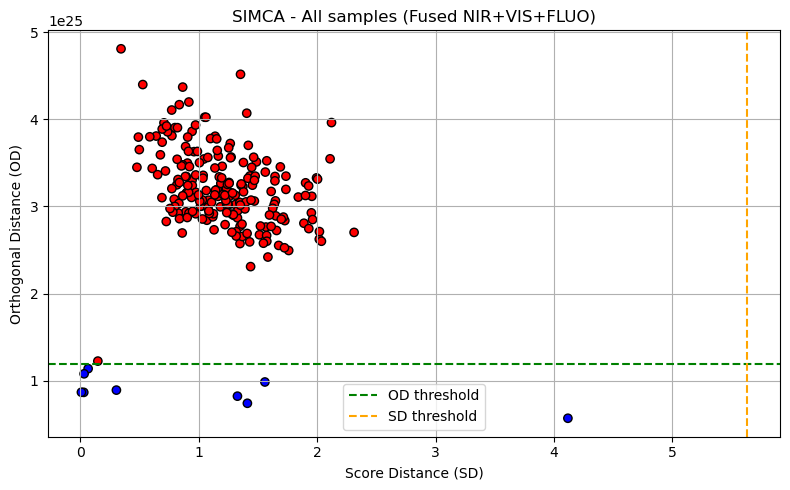

In [23]:
plt.figure(figsize=(8,5))
colors = np.where(inside, 'blue', 'red')
plt.scatter(res_all['SD'], res_all['OD'], c=colors, edgecolor='k')
plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')
plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA - All samples (Fused NIR+VIS+FLUO)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

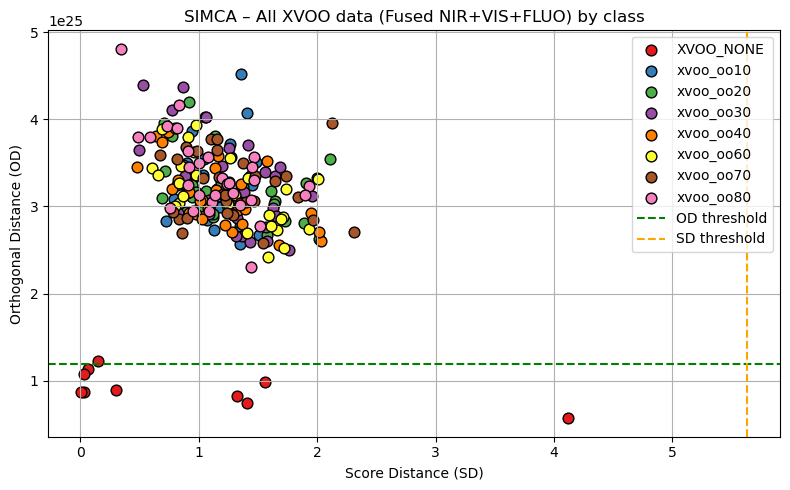

In [24]:
SD = res_all['SD']
OD = res_all['OD']

classes = np.unique(y_all)

contrast_colors = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#ffff33",
    "#a65628",
    "#f781bf",
    "#999999",
]

class_colors = {cls: contrast_colors[i % len(contrast_colors)] for i, cls in enumerate(classes)}

plt.figure(figsize=(8,5))

for cls in classes:
    idx = y_all == cls
    plt.scatter(
        SD[idx],
        OD[idx],
        color=class_colors[cls],
        edgecolor='k',
        label=cls,
        s=60
    )

plt.axhline(simca_fused.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
plt.axvline(simca_fused.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')

plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA – All XVOO data (Fused NIR+VIS+FLUO) by class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
y_true = np.array([label == "XVOO_NONE" for label in y_all])

y_pred = res_all['inside']

TP = np.sum((y_true == True) & (y_pred == True))
FN = np.sum((y_true == True) & (y_pred == False))
FP = np.sum((y_true == False) & (y_pred == True))
TN = np.sum((y_true == False) & (y_pred == False))

conf_matrix = pd.DataFrame(
    [[TP, FN],
     [FP, TN]],
    index=["True XVOO", "True MIX"],
    columns=["Predicted IN", "Predicted OUT"]
)

print("Confusion matrix (fused spectra):")
display(conf_matrix)

Confusion matrix (fused spectra):


,Predicted IN,Predicted OUT
True XVOO,9,1
True MIX,0,210


In [26]:
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Sensitivity (Recall for XVOO): {sensitivity*100:.2f}%")
print(f"Specificity (Rejection of MIX): {specificity*100:.2f}%")
print(f"Accuracy: {accuracy*100:.2f}%")

Sensitivity (Recall for XVOO): 90.00%
Specificity (Rejection of MIX): 100.00%
Accuracy: 99.55%


In [27]:
results_table = pd.DataFrame({
    "Sample index": np.arange(len(y_all)),
    "True label": y_all,
    "SIMCA accepted": y_pred,
    "Decision": np.where(y_pred, "Accepted", "Rejected"),
    "SD": res_all['SD'],
    "OD": res_all['OD']
})

results_table.head(10)

,Sample index,True label,SIMCA accepted,Decision,SD,OD
0,0,XVOO_NONE,True,Accepted,0.028552,8.659601e+24
1,1,XVOO_NONE,True,Accepted,0.008656,8.673138e+24
2,2,XVOO_NONE,True,Accepted,1.410683,7.407111e+24
3,3,XVOO_NONE,True,Accepted,0.065400,1.137972e+25
4,4,XVOO_NONE,False,Rejected,0.147498,1.224717e+25
5,5,XVOO_NONE,True,Accepted,1.558647,9.849296e+24
6,6,XVOO_NONE,True,Accepted,1.326714,8.223555e+24
7,7,XVOO_NONE,True,Accepted,4.118334,5.688816e+24
8,8,XVOO_NONE,True,Accepted,0.031359,1.078968e+25
9,9,XVOO_NONE,True,Accepted,0.304158,8.917505e+24
